In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

%matplotlib inline
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", font_scale=0.8, rc=custom_params)
%config InlineBackend.figure_format='retina'

# autoreload python modules on change
%load_ext autoreload
%autoreload 2

In [2]:
df_brains = [
    (746046, 561, "CTX"),
    (746045, 561, "CB"),
    (746043, 561, "SP"),
    (746041, 561, "CTX"),
    (744119, 561, "CTX"),
    (744117, 561, "CB"),
    (731907, 561, "TH"),
    (725231, 561, "SP"),
    (751035, 561, "TH"),
    (751024, 561, "CB"),
    (751023, 561, "CTX"),
    (751017, 561, "CB"),
    (751019, 561, "CB"),
    (755069, 561, "SP"),
    (755072, 561, "SP"),
    (755073, 561, "CTX"),
    (762196, 561, "SP"),
    (762199, 561, "CB"),
    (796810, 561, "PAG"),
    (796809, 561, "MOB"),
    (793603, 561, "iontoTH"),
    (791276, 561, "iontoTH"),
    (791270, 561, "iontoTH"),
    (791272, 561, "iontoTH"),
    (784354, 561, "MOB"),
    (784361, 561, "MOB"),
    (793600, 561, "PAG"),
    (793602, 561, "PAG"),
    (791275, 561, "PAG"),
    (785349, 561, "PAG"),
    (774450, 561, "SP"),
    (793594, 561, "SP"),
    (804461, 561, "MOB"),
    (804464, 561, "PAG"),
    (801624, 561, "iontoTH"),
    (793606, 561, "iontoTH"),
    (804462, 561, "iontoTH")
]

# Create a DataFrame
df_brains = pd.DataFrame(df_brains, columns=["brain_id", "channel", "injection_region"])

# Display the first few rows of the DataFrame
display(df_brains.head(10))

,brain_id,channel,injection_region
0,746046,561,CTX
1,746045,561,CB
2,746043,561,SP
3,746041,561,CTX
4,744119,561,CTX
5,744117,561,CB
6,731907,561,TH
7,725231,561,SP
8,751035,561,TH
9,751024,561,CB


In [3]:
# Function to load and filter data for a batch
def find_brain_file(brain_id, data_dirs):
    for data_dir in data_dirs:
        file_path = data_dir / f"{brain_id}_registered_pts.csv"
        if file_path.exists():
            return file_path, data_dir
    return None, None

def load_brain_data_multi_dirs(data_dirs, df_brains, batch_labels=None):
    all_dfs = []
    for i, brain_id in enumerate(df_brains["brain_id"]):
        file_path, found_dir = find_brain_file(brain_id, data_dirs)
        if file_path:
            try:
                df = pd.read_csv(file_path, index_col=0)
                df.columns = ['x', 'y', 'z', 'Location']
                df["brain_id"] = brain_id
                # Assign batch label based on directory index if provided
                if batch_labels:
                    batch_label = batch_labels[data_dirs.index(found_dir)]
                    df["batch"] = batch_label
                df_filtered = df[df["Location"] == "inside"]
                all_dfs.append(df_filtered)
            except Exception as e:
                print(f"Error processing brain_id {brain_id} in {found_dir}: {e}")
        else:
            print(f"File not found for brain_id: {brain_id} in any provided directory")
    return pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

In [4]:
# Define your data directories for both batches
data_dir_final = Path("~/capsule/data/Dbh-CreAi65_retrograde_soma_manual_proofread_10-14-25/final_results/").expanduser()
data_dirs = [data_dir_final] 
batch_labels = ["final"] 

# Load data from both batches
df_coordinates_ccf = load_brain_data_multi_dirs(data_dirs, df_brains, batch_labels=batch_labels)
# Drop Location column
df_coordinates_ccf = df_coordinates_ccf.drop(columns=["Location"])
# Merge with df_brains
df_ccf = pd.merge(df_brains, df_coordinates_ccf, on="brain_id")
df_ccf = df_ccf.rename(columns={"brain_id": "brain"})
# Display and check
display(df_ccf.head(10))
display (df_ccf.tail(10))

print(df_ccf["x"].min(), df_ccf["x"].max())
print(df_ccf["y"].min(), df_ccf["y"].max())
print(df_ccf["z"].min(), df_ccf["z"].max())

,brain,channel,injection_region,x,y,z,batch
0,746046,561,CTX,261.107788,160.238174,426.496399,final
1,746046,561,CTX,260.630951,162.411804,426.451996,final
2,746046,561,CTX,260.420593,163.047180,426.273346,final
3,746046,561,CTX,258.255768,168.814880,424.967255,final
4,746046,561,CTX,254.746948,170.891434,423.269836,final
5,746046,561,CTX,261.142914,162.907364,426.513367,final
6,746046,561,CTX,260.468414,167.904831,425.813324,final
7,746046,561,CTX,260.276489,165.495361,425.486053,final
8,746046,561,CTX,261.157013,163.304062,425.937988,final
9,746046,561,CTX,261.181763,161.949234,425.876923,final


,brain,channel,injection_region,x,y,z,batch
15866,804462,561,iontoTH,263.962616,166.511322,431.757385,final
15867,804462,561,iontoTH,262.048279,165.175034,433.484467,final
15868,804462,561,iontoTH,263.933838,166.230957,435.799072,final
15869,804462,561,iontoTH,262.851318,165.999817,435.734619,final
15870,804462,561,iontoTH,260.637604,165.981003,432.776520,final
15871,804462,561,iontoTH,263.691711,165.619492,432.194275,final
15872,804462,561,iontoTH,262.546051,166.008057,432.493774,final
15873,804462,561,iontoTH,260.063904,162.835693,430.424530,final
15874,804462,561,iontoTH,259.164307,157.521469,427.207153,final
15875,804462,561,iontoTH,263.216614,168.222412,426.585510,final


130.2820587158203 313.3256530761719
138.59121704101562 284.2338256835937
378.14114379882807 444.62493896484375


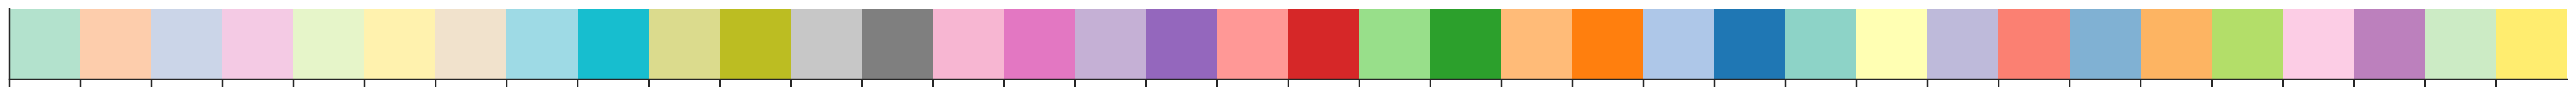

In [5]:
# Pastel2 without last color (grey)
pastel2 = sns.color_palette("Pastel2", 8)[:-1]

# Set3 without 9th color (index 8)
set3 = [c for i, c in enumerate(sns.color_palette("Set3", 12)) if i != 8]

# Tab20 reversed, without 9th and 10th colors (indices 8 and 9)
tab20_reversed = [c for i, c in enumerate(sns.color_palette("tab20", 20)[::-1]) if i not in [8, 9]]

# Combine palettes for 40 colors
large_palette = pastel2 + tab20_reversed + set3

# Visualize
sns.palplot(large_palette)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_core/properties.py:130: UserWarning: 
The color list has fewer values (36) than needed (37) and will cycle, which may produce an uninterpretable plot.
  warnings.warn(message, UserWarning)


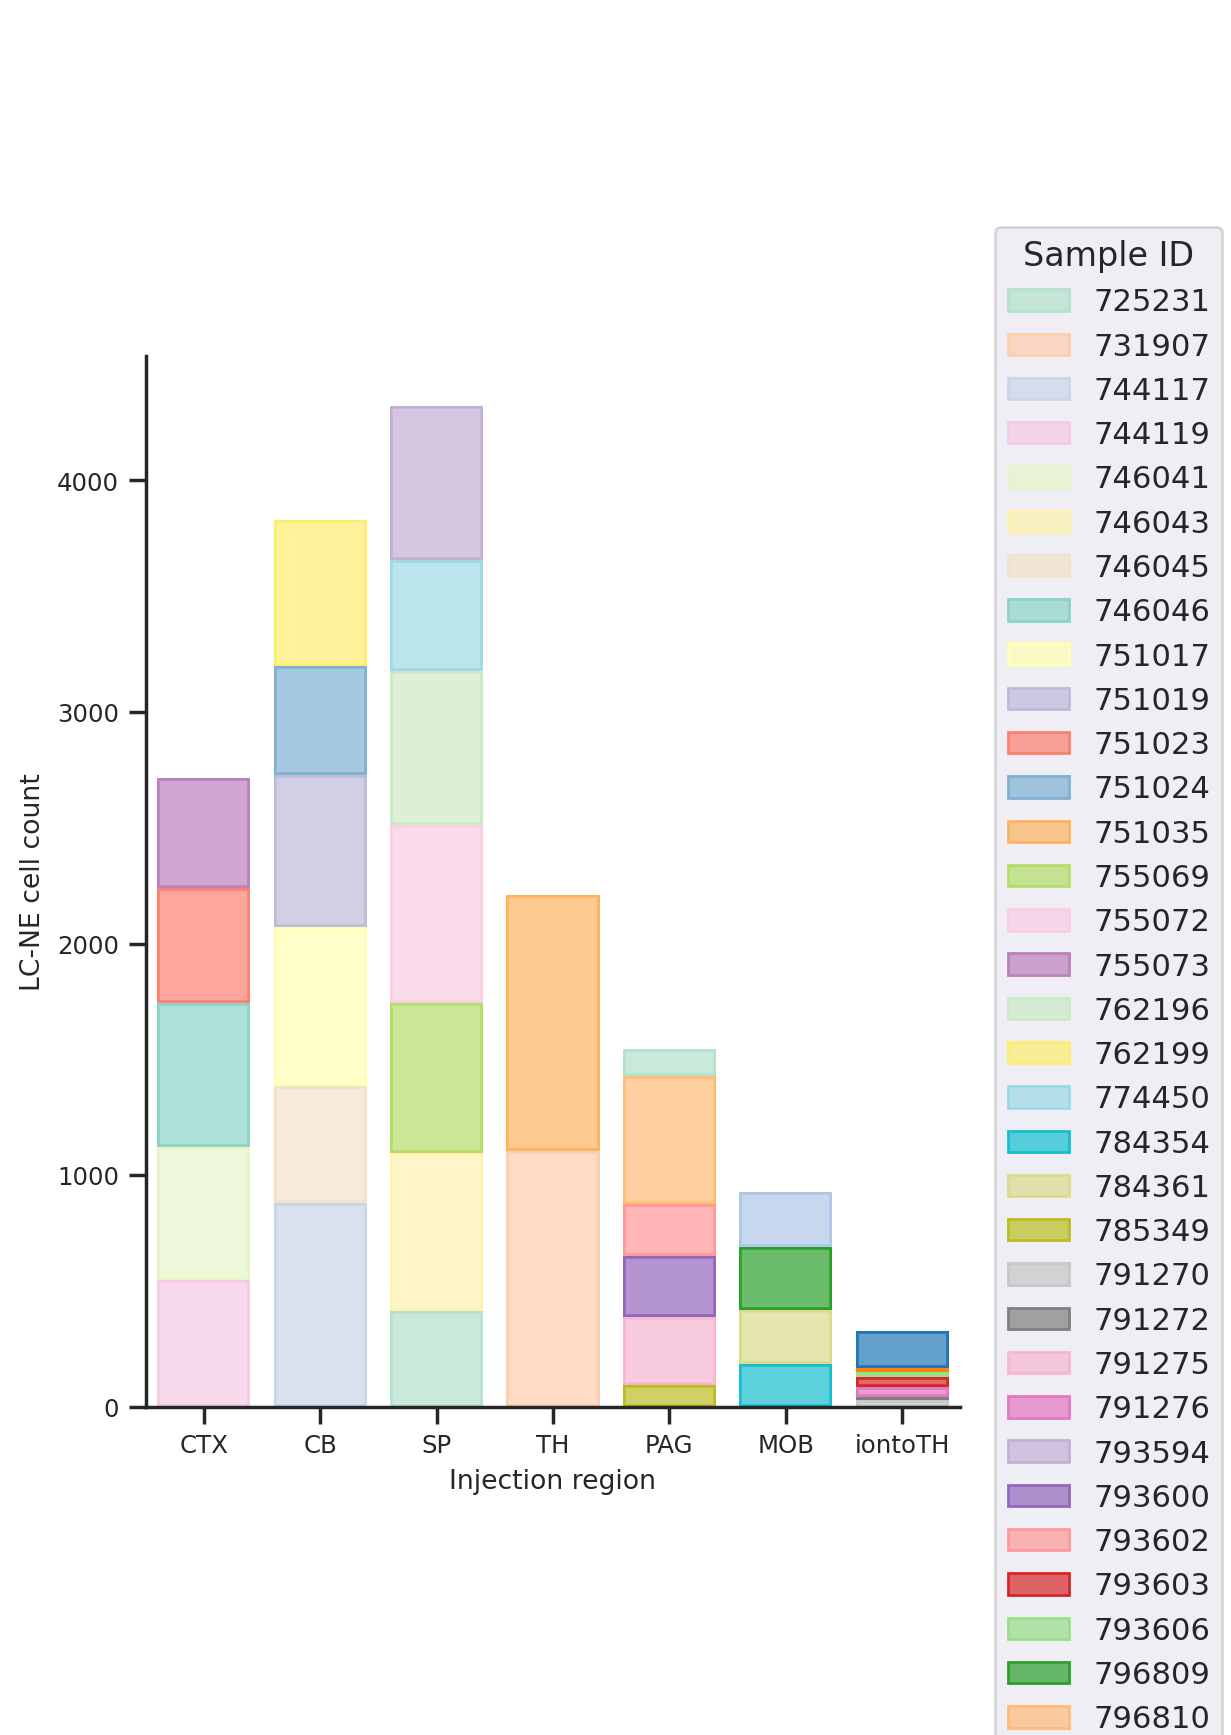

In [6]:
import seaborn.objects as so

# Get the number of unique brains
n_brains = df_ccf["brain"].nunique()

# Combine palettes for enough colors
# Pastel2 without last color (grey)
pastel2 = sns.color_palette("Pastel2", 8)[:-1]
# Set3 without 9th color (index 8)
set3 = [c for i, c in enumerate(sns.color_palette("Set3", 12)) if i != 8]
# Tab20 reversed, without 9th and 10th colors (indices 8 and 9)
tab20_reversed = [c for i, c in enumerate(sns.color_palette("tab20", 20)[::-1]) if i not in [8, 9]]
combined_palette = pastel2 + set3 + tab20_reversed

# Truncate to the number of unique brains
palette = combined_palette[:n_brains]

f, ax = plt.subplots(1, 1, figsize=(5, 6))
(
    so.Plot(df_ccf, x="injection_region", color="brain")
    .on(ax)
    .add(so.Bar(), so.Count(), so.Stack())
    .scale(color=palette, title="Brain")
    .label(x="Injection region", y="LC-NE cell count", color="Sample ID")
    .plot()
)
plt.tight_layout()
plt.show()

In [7]:
# save df at /results/
df_ccf.to_csv("/results/FINAL_manual_proofread_ccf_37brains.csv", index=False)